In [75]:
%matplotlib inline

import tensorflow as tf

import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers

import numpy as np
from numpy.random import seed, randint

# Getting the data

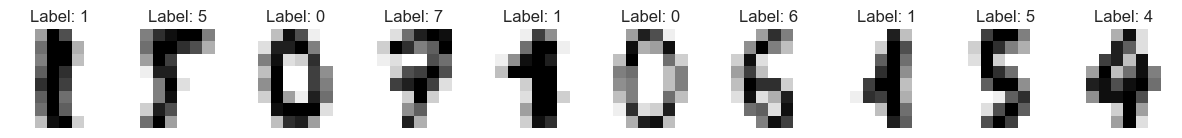

In [54]:
digits = load_digits()
# 28x28 pixels, low resolution

random_indices = np.random.choice(len(digits.images), 10, replace=False)
plt.figure(figsize=(15, 4))
for i, idx in enumerate(random_indices):
    plt.subplot(1, 10, i + 1)
    # Display the image (cmap='gray_r' shows dark pixels on a light background)
    plt.imshow(digits.images[idx], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f"Label: {digits.target[idx]}")
    plt.axis('off')

plt.show()

# Training the neural network

In [55]:
num_classes = 10
X = digits.data
y = digits.target
# one-hot encoding
Y = to_categorical(y, num_classes)

X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, stratify = Y)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.2, stratify=Y_train_val)
input_size = X[0].shape[0]

In [56]:
# seeds control the reproductability of randomness
seed(0) # numpy and standard python
tf.random.set_seed(0) # tensorflow

model = Sequential() # initialize a neural network
model.add(Input(shape=(input_size,))) # input layer
model.add(Dense(units = 32, activation='tanh')) # hidden layer
model.add(Dense(units = num_classes, activation='softmax')) # output layer

sgd = SGD(learning_rate = 0.1) # stochastic gradient descent
model.compile(loss = 'categorical_crossentropy', optimizer = sgd, metrics = ['accuracy'])

history = model.fit(X_train, Y_train, epochs = 10, batch_size = 50, verbose = 0, validation_split = 0.2)

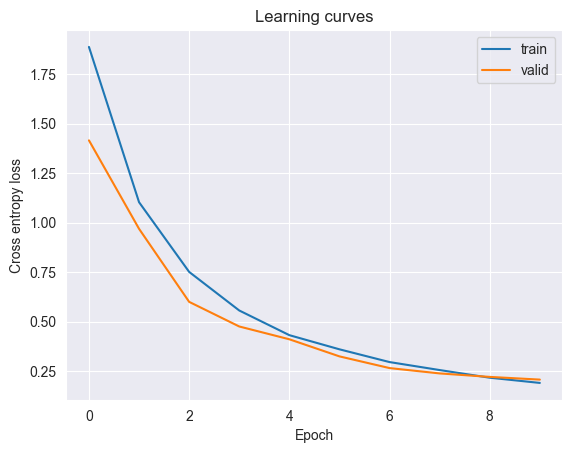

In [57]:
plt.figure()
plt.title("Learning curves")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy loss")
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'valid')
plt.legend()
plt.show()

In [58]:
# Use verbose=0 to hide the progress bars
train_results = model.evaluate(X_train, Y_train, verbose=0)
val_results = model.evaluate(X_val, Y_val, verbose=0)

print(f"Loss + accuracy on train data: {train_results}")
print(f"Loss + accuracy on validation data: {val_results}")

Loss + accuracy on train data: [0.18903571367263794, 0.9747606515884399]
Loss + accuracy on validation data: [0.29986846446990967, 0.9340277910232544]


# Consider misclassified digits

In [59]:
probabilities = np.array(model.predict(X_val))
predictions = np.argmax(probabilities, axis = 1) # what the model predicts
labels = np.argmax(Y_val, axis = 1) # what the actual labels are

print("Predictions = {}".format(predictions[0:30]))
print("Labels      = {}".format(labels[0:30]))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predictions = [3 7 7 7 1 2 4 4 2 8 5 9 1 3 3 2 1 0 2 0 0 1 3 7 8 6 7 9 1 7]
Labels      = [3 7 7 7 1 2 4 4 2 9 5 9 1 3 3 2 1 0 2 0 0 1 3 7 8 6 7 9 1 8]


In [60]:
misclas_idxs = np.argwhere(predictions != labels)

print(f"Total misclassifications in val set: {len(misclas_idxs)}")
print(f"Size of the validation set: {len(X_val)}")

Total misclassifications in val set: 19
Size of the validation set: 288


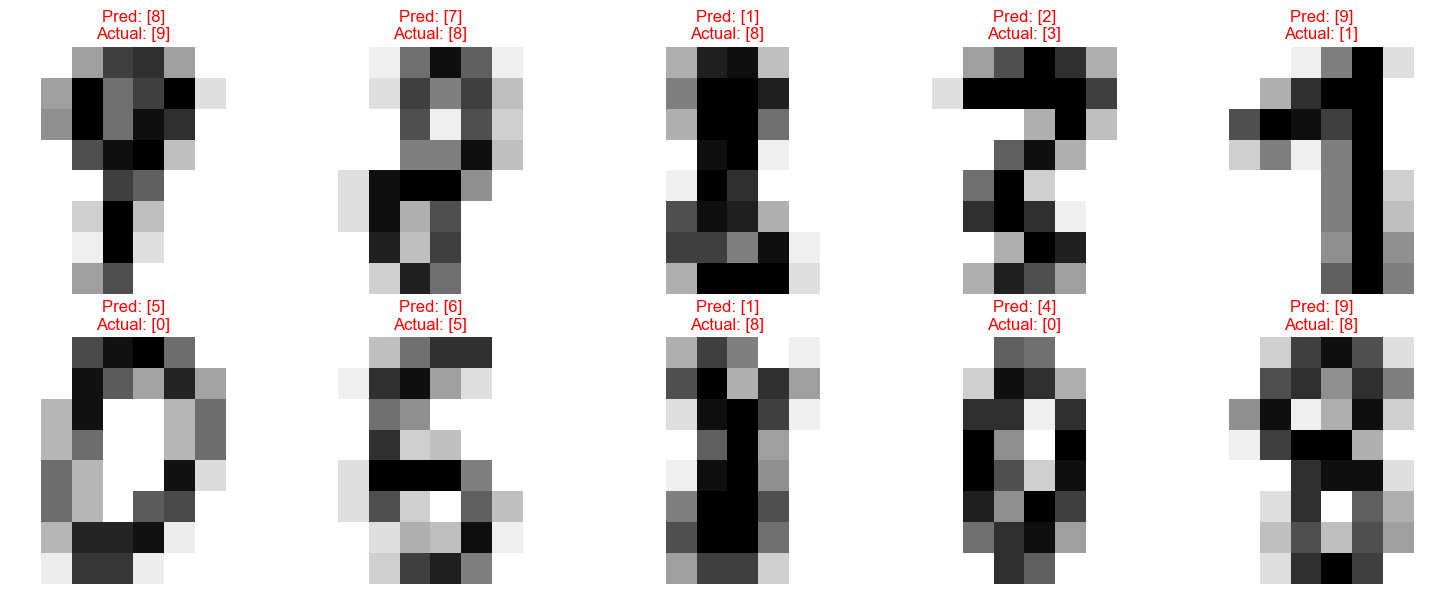

In [61]:
plt.figure(figsize=(15, 6))

for i, idx in enumerate(misclas_idxs[:10]):
    plt.subplot(2, 5, i + 1)
    img = X_val[idx].reshape(8, 8)
    plt.imshow(img, cmap=plt.cm.gray_r)
    plt.title(f"Pred: {predictions[idx]}\nActual: {labels[idx]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

There are several ways we could potentially optimize the algorithm for better performance (e.g., higher accuracy on the validation set):

 - Data Preprocessing:
    - Scaling: Scale input values to [0, 1] or [-1, 1].
 - Network Architecture:
    - Activation Function: Change tanh to relu.
    - Network Depth/Width: Add layers or increase units per layer.
- Optimizer:
    - (Algorithm: Switch from SGD to Adam) - only if you can explain adaptive learning rate.
    - Learning Rate: Tune the learning rate.
 - Regularization (to prevent overfitting):
    - Dropout: Add Dropout layers.
    - L1/L2 Regularization: Add kernel regularizers.
 - Training Process:
    - Epochs: Increase the number of training epochs.
    - Early Stopping: Implement EarlyStopping callback.
    - Batch Size: Experiment with different batch sizes.

Recommendation:

A good starting point would be to:

 - Scale the input data X to [0, 1].
 - Change the hidden layer activation to relu.
 - Switch the optimizer to Adam (using its default learning rate initially).
 - Increase the number of epochs significantly (e.g., 100)
 - Add EarlyStopping based on val_loss.

# Optimized Model

In [62]:
# Reload and scale data for the optimized model
digits_opt = load_digits()
X_opt = digits_opt.data / 16.0 # Scale data to [0, 1]
y_opt = digits_opt.target
Y_opt = to_categorical(y_opt, num_classes)
X_train_val_opt, X_test_opt, Y_train_val_opt, Y_test_opt = train_test_split(X_opt, Y_opt, test_size=0.2, stratify = y_opt) # Use scaled X_opt and Y_opt
X_train_opt, X_val_opt, Y_train_opt, Y_val_opt = train_test_split(X_train_val_opt, Y_train_val_opt, test_size=0.2, stratify = Y_train_val_opt)
input_size_opt = X_opt[0].shape[0]

In [63]:
# Define the optimized model
seed(1) # Use a different seed for comparison if desired
tf.random.set_seed(1)

model_opt = Sequential() # Initialize a new neural network
model_opt.add(Input(shape=(input_size_opt,)))  # Input layer
model_opt.add(Dense(units = 32, activation='relu')) # Use relu activation in the hidden layer
model_opt.add(Dense(units = num_classes, activation='softmax')) # Output layer

adam_opt = Adam() # Use Adam optimizer
model_opt.compile(loss = 'categorical_crossentropy', optimizer = adam_opt, metrics = ['accuracy'])

model_opt.summary() # Display model architecture

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,410 (9.41 KB)

 Trainable params: 2,410 (9.41 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Define EarlyStopping callback
early_stopping_opt = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the optimized model
history_opt = model_opt.fit(X_train_opt, Y_train_opt, 
                            epochs = 100, # Increased epochs
                            batch_size = 50, 
                            verbose = 0, 
                            validation_split = 0.2, 
                            callbacks=[early_stopping_opt]) # Added callback

print(f"Training finished after {len(history_opt.history['loss'])} epochs.")

Training finished after 100 epochs.


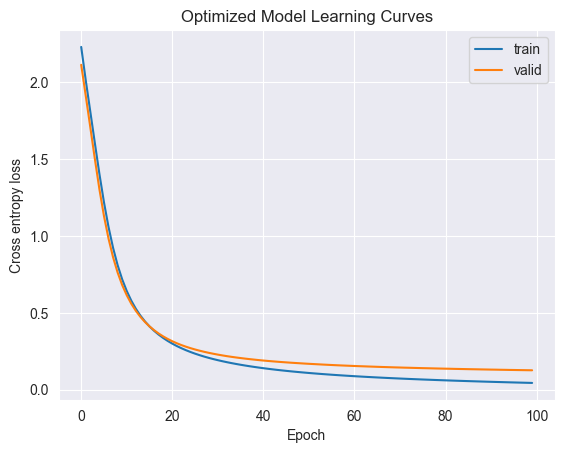

In [65]:
# Plot learning curves for the optimized model
plt.figure()
plt.title("Optimized Model Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy loss")
plt.plot(history_opt.history['loss'], label = 'train')
plt.plot(history_opt.history['val_loss'], label = 'valid')
plt.legend()
plt.show()

In [66]:
# Evaluate the optimized model
print("Optimized Model - Loss + accuracy on train data: {}".format(model_opt.evaluate(X_train_opt, Y_train_opt, verbose=0)))
print("Optimized Model - Loss + accuracy on validation data: {}".format(model_opt.evaluate(X_val_opt, Y_val_opt, verbose=0)))

Optimized Model - Loss + accuracy on train data: [0.05957195162773132, 0.9895561337471008]
Optimized Model - Loss + accuracy on validation data: [0.10971556603908539, 0.9618055820465088]


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Optimized Predictions = [7 8 6 3 4 2 8 0 0 8 8 8 6 8 4 0 3 4 6 3 8 4 1 8 8 3 2 5 5 0]
Optimized Labels      = [7 6 6 3 4 2 8 0 0 8 8 8 6 8 5 0 3 4 6 3 8 4 1 8 8 3 2 3 5 0]
Total misclassifications in validation set: 11


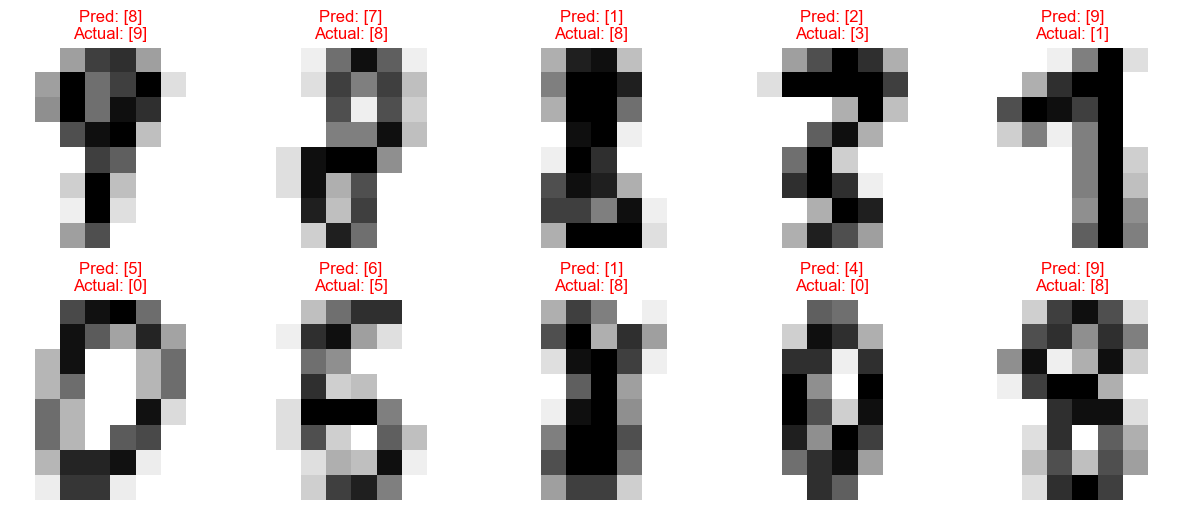

In [69]:
# Consider misclassified digits for the optimized model
probabilities_opt = np.array(model_opt.predict(X_val_opt))
predictions_opt = np.argmax(probabilities_opt, axis = 1)
labels_opt = np.argmax(Y_val_opt, axis = 1)

print("Optimized Predictions = {}".format(predictions_opt[0:30]))
print("Optimized Labels      = {}".format(labels_opt[0:30]))

misclas_idxs_opt = np.argwhere(predictions_opt != labels_opt)

print(f"Total misclassifications in validation set: {len(misclas_idxs_opt)}")

if len(misclas_idxs_opt) > 0:
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(misclas_idxs[:10]):
        plt.subplot(2, 5, i + 1)
        img = X_val[idx].reshape(8, 8)
        plt.imshow(img, cmap=plt.cm.gray_r)
        plt.title(f"Pred: {predictions[idx]}\nActual: {labels[idx]}", color='red')
        plt.axis('off')
else:
    print("No misclassifications found on the validation set for the optimized model!")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


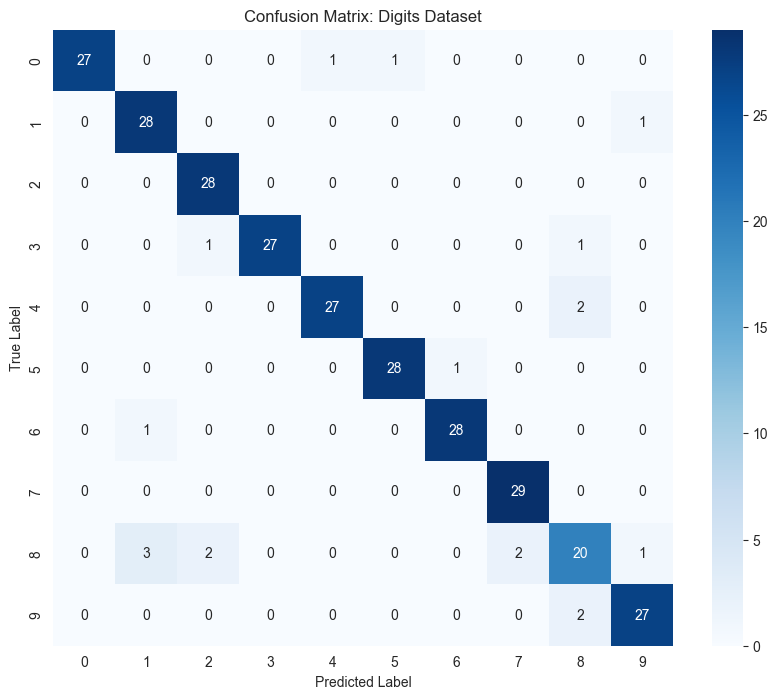

In [76]:
val_probs = model.predict(X_val)
val_preds = np.argmax(val_probs, axis=1)
val_labels = np.argmax(Y_val, axis=1)

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Digits Dataset')
plt.show()

## Evaluate on test set

In [70]:
# finally evaluate on test set
print("Optimized Model - Loss + accuracy on train data: {}".format(model_opt.evaluate(X_train_opt, Y_train_opt, verbose=0)))
print("Optimized Model - Loss + accuracy on validation data: {}".format(model_opt.evaluate(X_val_opt, Y_val_opt, verbose=0)))
print("Optimized Model - Loss + accuracy on test data: {}".format(model_opt.evaluate(X_test_opt, Y_test_opt, verbose=0)))

Optimized Model - Loss + accuracy on train data: [0.05957195162773132, 0.9895561337471008]
Optimized Model - Loss + accuracy on validation data: [0.10971556603908539, 0.9618055820465088]
Optimized Model - Loss + accuracy on test data: [0.12258648127317429, 0.9750000238418579]


In [72]:
probabilities_opt = np.array(model_opt.predict(X_test_opt))
predictions_opt = np.argmax(probabilities_opt, axis = 1)
labels_opt = np.argmax(Y_test_opt, axis = 1)

misclas_idxs_opt = np.argwhere(predictions_opt != labels_opt)

print(f"Total misclassifications in test set: {len(misclas_idxs_opt)}")
print(f"Total size of test set: {len(Y_test_opt)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Total misclassifications in test set: 9
Total size of test set: 360


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


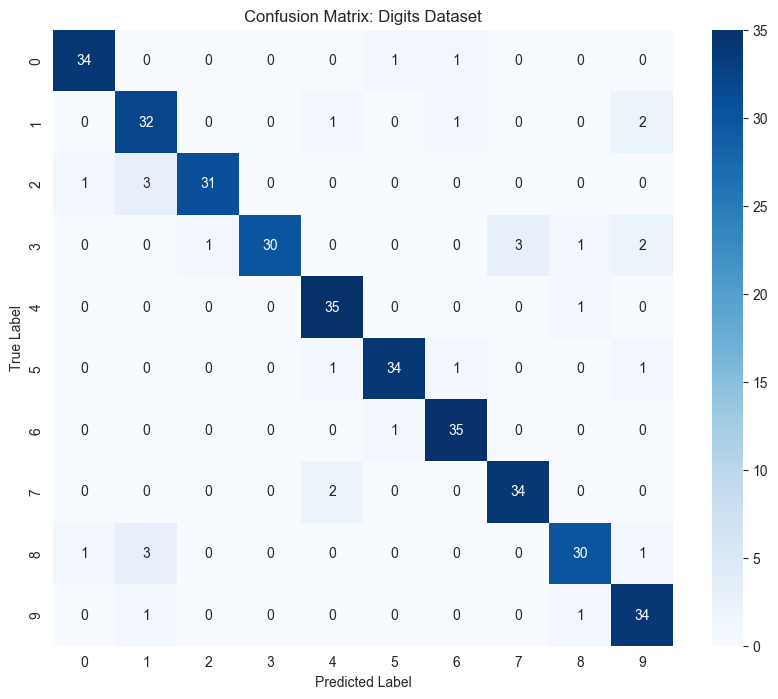

In [77]:
test_probs = model.predict(X_test)
test_preds = np.argmax(test_probs, axis=1)
test_labels = np.argmax(Y_test, axis=1)

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Digits Dataset')
plt.show()